# 2장 1강: 시계열 데이터의 이해와 정상성 진단

## 실습 목표

이번 실습에서는 **Bike Sharing Demand** 데이터를 이용해 시간에 따른 자전거 대여량 변화를 확인합니다.

- 시계열 데이터에서 **시간 순서가 중요한 이유**를 확인합니다.
- 선 그래프와 시계열 분해를 이용해 **Trend / Seasonality / Residual**을 확인합니다.
- 이동평균을 이용해 데이터의 평균적인 수준 변화를 살펴봅니다.
- **ADF Test**를 이용해 정상성을 진단합니다.
- 정상성을 만족하지 않는 경우 **1차 차분**을 적용하고 ADF Test를 다시 수행합니다.

> 이 실습에서는 교안에서 다룬 내용만 사용합니다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- statsmodels
- 데이터: `data/Bike_Sharing_Demand.csv`

### 주요 컬럼

| 컬럼 | 의미 |
|---|---|
| `datetime` | 자전거 대여 기록 시각 |
| `casual` | 비등록 사용자의 대여 수 |
| `registered` | 등록 사용자의 대여 수 |
| `count` | 전체 자전거 대여 수 |

`count`는 `casual + registered`로 구성된 전체 대여량입니다.

## 실습 준비

먼저 데이터를 불러온 뒤 다음 내용을 확인합니다.

1. 데이터 크기와 상위 행
2. 주요 컬럼의 자료형
3. 결측치
4. `datetime`을 날짜/시간 자료형으로 변환
5. 시간 순서대로 정렬
6. 일별·월별 대여량 데이터 준비

> 일별·월별 집계 코드는 이후 시계열 실습을 위한 **준비 코드**로 제공됩니다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

bike = pd.read_csv("data/Bike_Sharing_Demand.csv")

print("데이터 크기:", bike.shape)
display(bike.head())

print("\n[자료형]")
display(bike[["datetime", "casual", "registered", "count"]].dtypes.to_frame("dtype"))

print("\n[결측치]")
display(bike[["datetime", "casual", "registered", "count"]].isna().sum().to_frame("missing"))

데이터 크기: (10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1



[자료형]


,dtype
datetime,str
casual,int64
registered,int64
count,int64



[결측치]


,missing
datetime,0
casual,0
registered,0
count,0


In [2]:
# datetime 변환 및 시간 순서 정렬
bike["datetime"] = pd.to_datetime(bike["datetime"])
bike = bike.sort_values("datetime").reset_index(drop=True)

print("최초 시각:", bike["datetime"].min())
print("마지막 시각:", bike["datetime"].max())
display(bike.head())

최초 시각: 2011-01-01 00:00:00
마지막 시각: 2012-12-19 23:00:00


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [3]:
# 일별 시계열 준비
bike["date"] = bike["datetime"].dt.date

daily = (bike.groupby("date", as_index=False)[["count", "casual", "registered"]].sum())

daily["date"] = pd.to_datetime(daily["date"])

# 월별 시계열 준비
bike["month"] = bike["datetime"].dt.to_period("M").astype(str)

monthly = (bike.groupby("month", as_index=False)["count"].sum())

monthly["month"] = pd.to_datetime(monthly["month"])

print("[일별 데이터]")
display(daily.head())

print("\n[월별 데이터]")
display(monthly.head())

[일별 데이터]


,date,count,casual,registered
0,2011-01-01,985,331,654
1,2011-01-02,801,131,670
2,2011-01-03,1349,120,1229
3,2011-01-04,1562,108,1454
4,2011-01-05,1600,82,1518



[월별 데이터]


,month,count
0,2011-01-01,23552
1,2011-02-01,32844
2,2011-03-01,38735
3,2011-04-01,50517
4,2011-05-01,79713


---

# 필수 1. 시간 흐름과 시계열 패턴 확인

## 배경

시계열 데이터는 값 자체뿐만 아니라 **언제 관측되었는지와 어떤 순서로 나타났는지**가 중요합니다.

Bike Sharing Demand 데이터의 전체 대여량 `count`를 시간 순서대로 확인하고, 월별 대여량을 **Trend / Seasonality / Residual**로 나누어 살펴봅니다.

## 문제 1. 일별 대여량을 시간 순서대로 확인하세요.

### 요구사항

1. `daily["date"]`를 x축, `daily["count"]`를 y축으로 선 그래프를 그립니다.
2. 그래프 제목을 `Daily Bike Rentals`로 설정합니다.
3. 시간의 흐름에 따라 대여량의 전반적인 수준이 어떻게 변화하는지 설명합니다.

### 확인 포인트

- 시계열 그래프에서는 시간 순서를 유지했는가?
- 단순히 개별 값만 보는 것이 아니라 전체적인 흐름을 확인했는가?

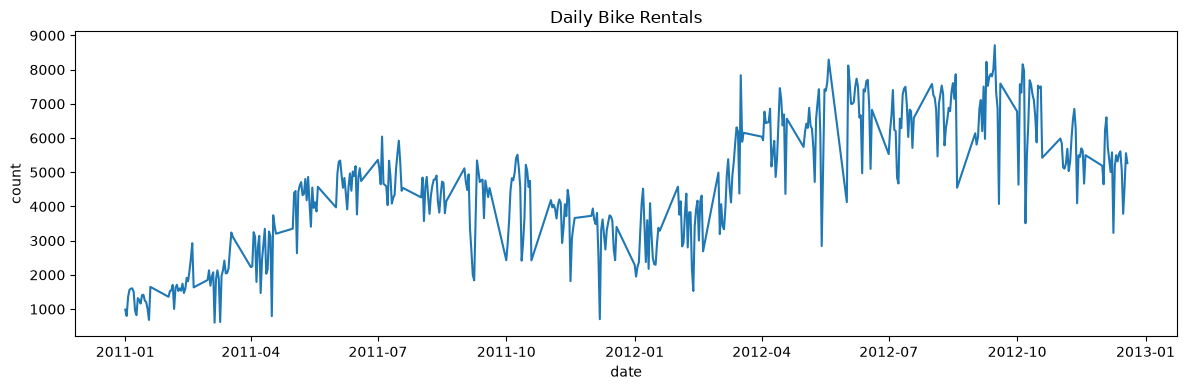

In [4]:
# TODO
# daily["date"]와 daily["count"]를 이용해 선 그래프를 그려보세요.
plt.figure(figsize=(12, 4))
plt.plot(daily["date"], daily["count"])
plt.title("Daily Bike Rentals")
plt.xlabel("date")
plt.ylabel("count")
plt.tight_layout()
plt.show()


### Q1. 왜 `daily` 데이터를 무작위로 섞지 않고 날짜 순서대로 확인해야 할까요?

**답변:**  
시계열은 관측 시점과 순서가 패턴(추세·계절성)의 핵심이므로, 섞으면 시간 의존 구조가 사라져 흐름을 잘못 해석하게 됩니다.


## 문제 2. 월별 대여량을 시계열 분해하세요.

### 요구사항

1. `monthly`의 `month`를 인덱스로 설정합니다.
2. `seasonal_decompose()`를 사용합니다.
3. `model="additive"`를 사용합니다.
4. 월별 데이터의 1년 반복 주기를 확인하기 위해 `period=12`를 사용합니다.
5. 결과에서 `Observed`, `Trend`, `Seasonal`, `Residual`을 확인합니다.

### 확인 포인트

- `period=12`의 의미를 이해했는가?
- Trend / Seasonality / Residual을 구분할 수 있는가?

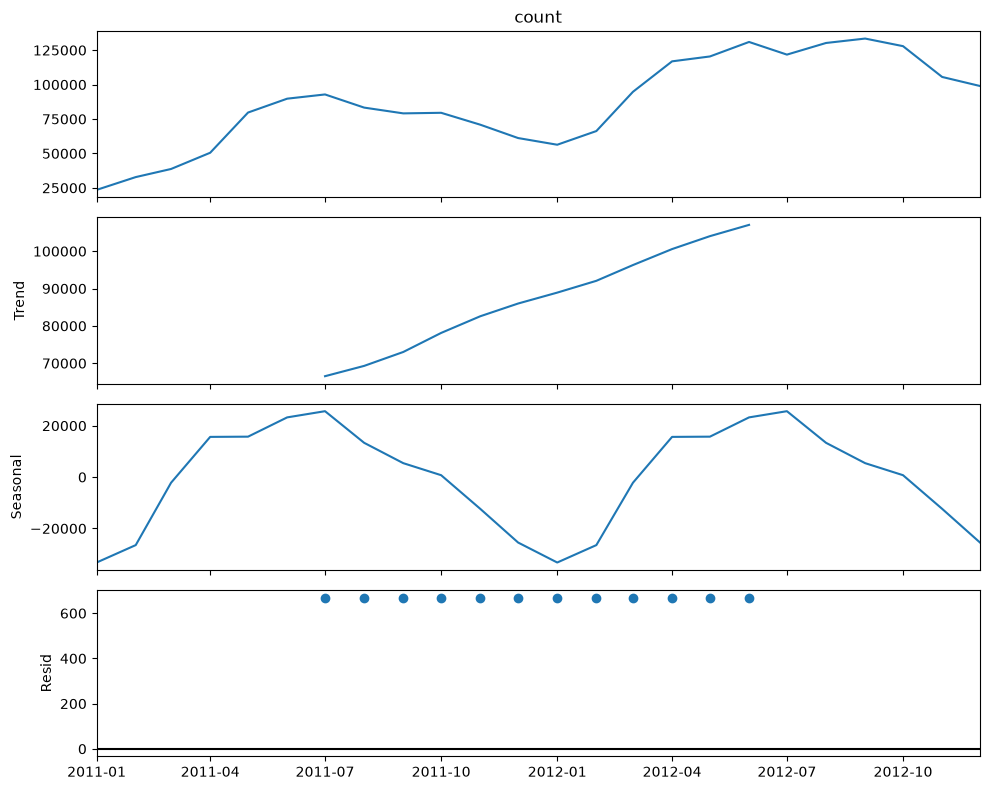

In [5]:
# TODO
# seasonal_decompose()를 이용해 월별 count를 분해해보세요.
monthly_decomp = monthly.set_index("month")["count"]
result = seasonal_decompose(monthly_decomp, model="additive", period=12)
fig = result.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()


### Q2. 다음 설명을 각각 Trend / Seasonality / Residual과 연결하세요.

- 시간이 지나면서 나타나는 장기적인 증가 또는 감소 → **Trend**
- 일정한 시간 간격을 두고 반복되는 변화 → **Seasonality**
- 추세와 계절성을 제외하고 남은 변동 → **Residual**

**답변:**  
위와 같이 Trend / Seasonality / Residual로 연결합니다.


---

# 필수 2. 정상성 진단과 1차 차분

## 배경

정상성은 시간이 지나도 시계열의 **평균적인 수준과 변동의 특성이 크게 달라지지 않는 성질**입니다.

이번 문제에서는 일별 전체 대여량 `count`의 이동평균을 확인하고, ADF Test를 이용해 정상성을 판단합니다. 정상성을 만족한다고 보기 어렵다면 1차 차분을 수행한 뒤 다시 ADF Test를 진행합니다.

## 문제 1. 이동평균으로 평균 수준의 변화를 확인하세요.

### 요구사항

1. `daily["count"]`의 최근 7개 값 이동평균을 계산하여 `rolling_mean` 컬럼에 저장합니다.
2. 원본 `count`와 `rolling_mean`을 같은 그래프에 나타냅니다.
3. 이동평균이 시간에 따라 변하는지 확인합니다.

### 확인 포인트

- `rolling(window=7).mean()`을 사용했는가?
- 이동평균이 개별 값의 작은 변동을 줄여 전체 수준을 보기 위한 방법임을 이해했는가?

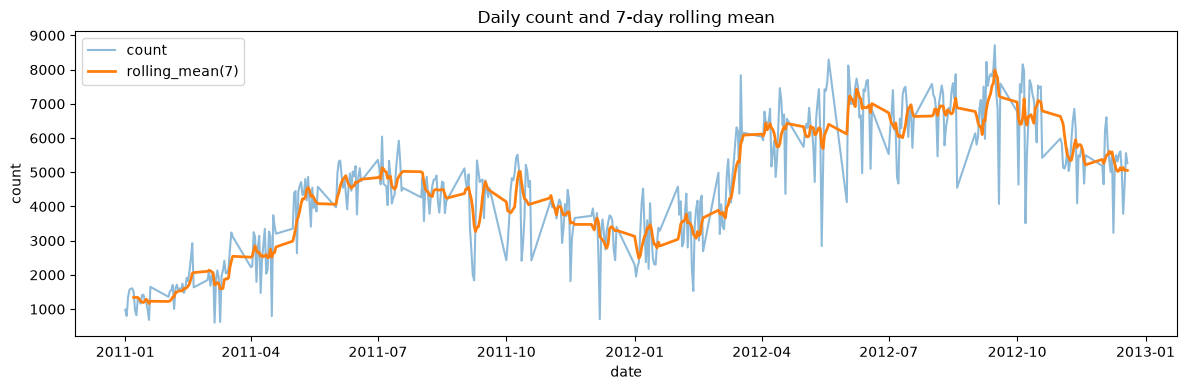

In [6]:
# TODO
# 7개 값 이동평균을 계산하고 원본 count와 함께 시각화하세요.
daily = daily.copy()
daily["rolling_mean"] = daily["count"].rolling(window=7).mean()

plt.figure(figsize=(12, 4))
plt.plot(daily["date"], daily["count"], label="count", alpha=0.5)
plt.plot(daily["date"], daily["rolling_mean"], label="rolling_mean(7)", linewidth=2)
plt.title("Daily count and 7-day rolling mean")
plt.xlabel("date")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()


## 문제 2. 원본 일별 대여량에 ADF Test를 수행하세요.

### 요구사항

1. `adfuller()`를 이용해 `daily["count"]`를 검정합니다.
2. ADF Statistic과 p-value를 출력합니다.
3. 유의수준 0.05를 기준으로 정상성을 판단합니다.

### 판단 기준

- `p-value < 0.05` → 귀무가설 기각 → 정상성을 만족한다고 판단
- `p-value ≥ 0.05` → 귀무가설을 기각하지 못함 → 정상성을 만족한다고 보기 어려움

In [7]:
# TODO
# 원본 daily["count"]에 ADF Test를 수행하세요.
adf_result = adfuller(daily["count"])
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
if adf_result[1] < 0.05:
    print("유의수준 0.05에서 정상성을 갖는다고 볼 수 있습니다.")
else:
    print("유의수준 0.05에서 정상성을 갖는다고 보기 어렵습니다.")


ADF Statistic: -2.002469176220279
p-value: 0.285491502028123
유의수준 0.05에서 정상성을 갖는다고 보기 어렵습니다.


C:\Users\k10k2\AppData\Local\Temp\ipykernel_27088\1208282587.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(daily["count"])


### Q3. 원본 데이터의 p-value를 기준으로 정상성을 어떻게 판단할 수 있나요?

**답변:**  
p-value가 0.05보다 작으면 단위근 귀무가설을 기각하여 정상성이라고 판단하고, 0.05 이상이면 정상성이라고 보기 어렵다고 판단합니다. (실제 수치는 위 셀 출력값을 근거로 합니다.)


## 문제 3. 1차 차분 후 정상성을 다시 확인하세요.

### 요구사항

1. `.diff()`를 이용해 `daily["count"]`를 1차 차분합니다.
2. 첫 번째 `NaN`은 `dropna()`로 제거합니다.
3. 차분된 값을 선 그래프로 나타냅니다.
4. 차분 데이터에 ADF Test를 다시 수행합니다.
5. 차분 전과 차분 후 p-value를 비교하여 정상성 변화를 설명합니다.

### 확인 포인트

- 차분값이 `현재 값 - 이전 값`이라는 것을 이해했는가?
- 차분 후 데이터의 의미가 **일별 대여량 → 이적 관측일 대비 대여량 변화**로 달라짐을 이해했는가?
- 차분 후 ADF Test를 다시 수행했는가?

<Figure size 1200x400 with 0 Axes>

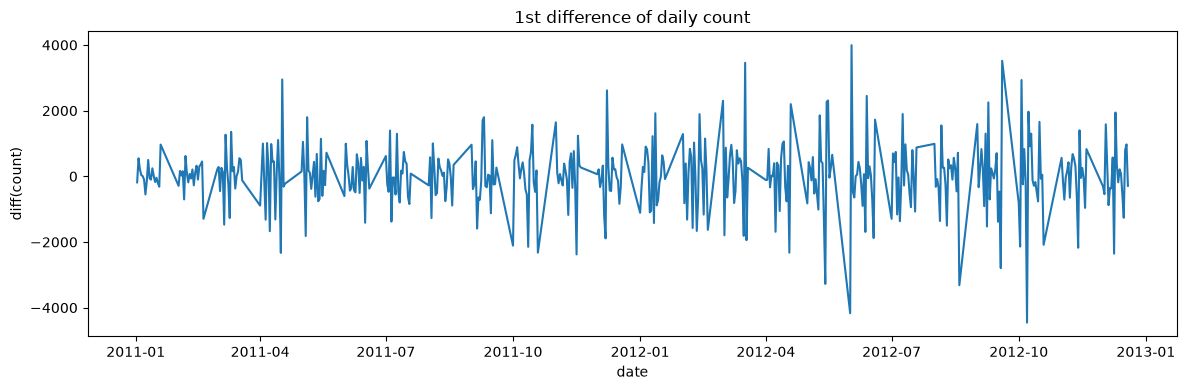

ADF Statistic (diff): -11.751565383174505
p-value (diff): 1.2057220051150929e-21


C:\Users\k10k2\AppData\Local\Temp\ipykernel_27088\980569718.py:17: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_diff = adfuller(daily_diff)


In [8]:
# TODO
# 1차 차분 → 시각화 → ADF Test 재실행 순서로 진행하세요.
daily_diff = daily["count"].diff().dropna()

plt.figure(figsize=(12, 4))
plt.plot(daily.loc[daily_diff.index, "date"] if "date" in daily.columns else daily_diff.index, daily_diff.values)
# date 정렬 인덱스 맞추기
plt.clf()
plt.figure(figsize=(12, 4))
plt.plot(daily["date"].iloc[1:], daily_diff.values)
plt.title("1st difference of daily count")
plt.xlabel("date")
plt.ylabel("diff(count)")
plt.tight_layout()
plt.show()

adf_diff = adfuller(daily_diff)
print("ADF Statistic (diff):", adf_diff[0])
print("p-value (diff):", adf_diff[1])


### Q4. 차분 전과 차분 후 데이터의 의미는 어떻게 달라지나요?

**답변:**  
차분 전은 각 시점의 절대 대여량 수준이고, 1차 차분 후는 전일 대비 변화량(증가·감소)을 나타냅니다. 평균 수준의 추세를 제거해 정상성에 가까워지도록 만드는 전처리입니다.


---

# 과제 1. 등록 사용자 대여량의 정상성 진단

## 배경

필수 2에서는 전체 대여량 `count`를 이용해 정상성 진단과 차분을 수행했습니다.

이번에는 같은 과정을 **등록 사용자 대여량 `registered`**에 직접 적용합니다.

> 과제는 필수 실습에서 연습한 방법을 동일하게 적용하는 수준입니다.

## 요구사항

1. `daily["registered"]`를 날짜 순서대로 선 그래프로 나타냅니다.
2. 최근 7개 값의 이동평균을 계산하여 원본 데이터와 함께 나타냅니다.
3. 원본 `registered`에 ADF Test를 수행합니다.
4. p-value를 기준으로 정상성을 판단합니다.
5. 정상성을 만족한다고 보기 어렵다면 1차 차분합니다.
6. 1차 차분을 수행한 경우, 차분 데이터에 ADF Test를 다시 수행합니다.
7. 원본과 차분 데이터의 p-value를 근거로 정상성 판단을 설명합니다. 차분하지 않았다면 그 이유를 설명합니다.
8. 진단 결과를 근거로 원본 데이터를 사용할지, 1차 차분한 데이터를 사용할지, 추가 진단이 필요한지 선택하고 이유를 설명합니다.

### 확인 포인트

- 원본 데이터의 시간 흐름을 확인했는가?
- 이동평균으로 평균 수준의 변화를 확인했는가?
- ADF Test의 p-value를 0.05와 비교했는가?
- 필요한 경우 1차 차분 후 ADF Test를 다시 수행했는가?
- 결과를 코드 출력값을 근거로 설명했는가?
- ADF 검정 결과와 그래프를 근거로 이후 모델링 방향을 선택했는가?


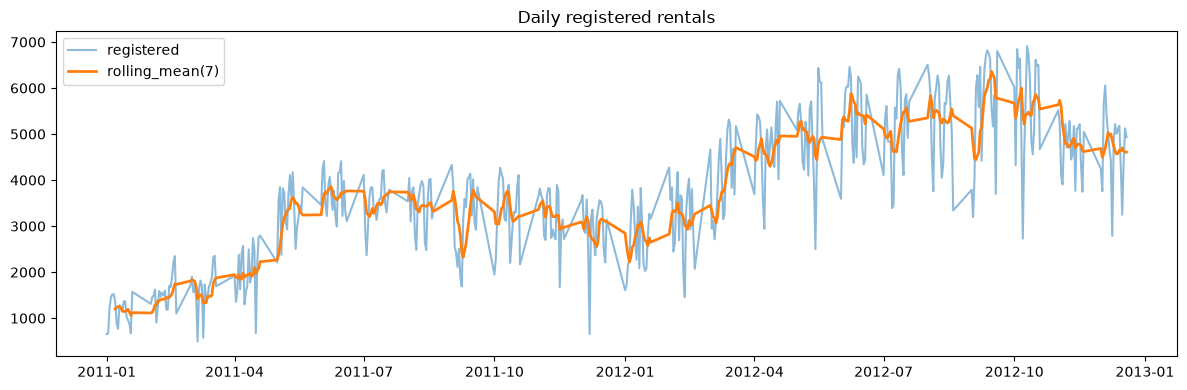

[원본 registered] ADF: -1.9069616350007472 p-value: 0.32879325858212327


C:\Users\k10k2\AppData\Local\Temp\ipykernel_27088\1662096631.py:15: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_reg = adfuller(daily["registered"])


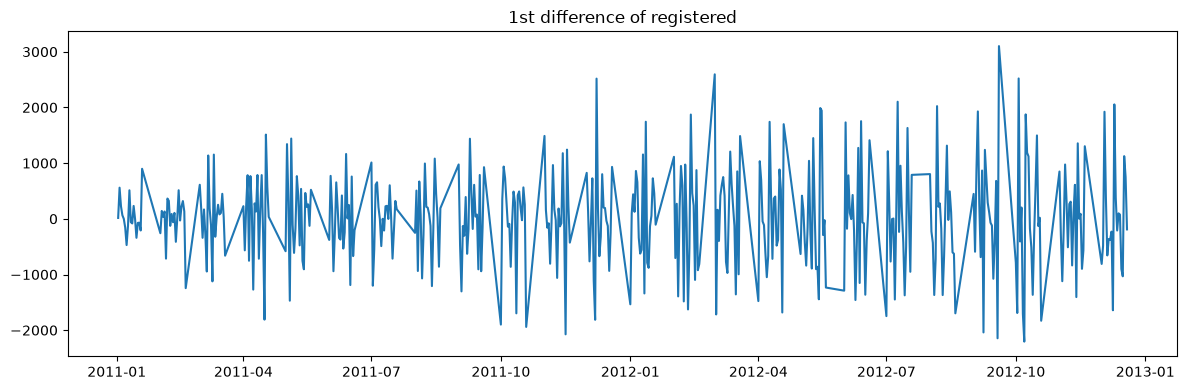

[1차 차분 registered] ADF: -6.353678332846846 p-value: 2.5738584410437914e-08

해석: 원본 p-value와 0.05를 비교하고, 필요 시 차분 후 정상성 개선 여부를 확인하세요.


C:\Users\k10k2\AppData\Local\Temp\ipykernel_27088\1662096631.py:25: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_reg_diff = adfuller(reg_diff)


In [9]:
# TODO
# 시각화 → 최근 7개 값 이동평균 → 원본 ADF Test
# → 필요 시 1차 차분 및 ADF Test 재실행 → 결과 비교
# Q5·Q6에는 출력값과 그래프를 근거로 해석과 모델링 방향을 작성하세요.

plt.figure(figsize=(12, 4))
plt.plot(daily["date"], daily["registered"], label="registered", alpha=0.5)
daily["registered_ma7"] = daily["registered"].rolling(window=7).mean()
plt.plot(daily["date"], daily["registered_ma7"], label="rolling_mean(7)", linewidth=2)
plt.title("Daily registered rentals")
plt.legend()
plt.tight_layout()
plt.show()

adf_reg = adfuller(daily["registered"])
print("[원본 registered] ADF:", adf_reg[0], "p-value:", adf_reg[1])

reg_diff = daily["registered"].diff().dropna()
plt.figure(figsize=(12, 4))
plt.plot(daily["date"].iloc[1:], reg_diff.values)
plt.title("1st difference of registered")
plt.tight_layout()
plt.show()

adf_reg_diff = adfuller(reg_diff)
print("[1차 차분 registered] ADF:", adf_reg_diff[0], "p-value:", adf_reg_diff[1])

print("\n해석: 원본 p-value와 0.05를 비교하고, 필요 시 차분 후 정상성 개선 여부를 확인하세요.")


### Q5. 원본 등록 사용자 대여량의 ADF 검정 결과를 어떻게 해석할 수 있나요? 차분했다면 차분 전후 결과를 비교하고, 차분하지 않았다면 그 이유를 설명하세요.

**답변:**
원본 `registered`의 ADF p-value를 0.05와 비교합니다. p≥0.05이면 정상성이라고 보기 어려워 1차 차분을 적용했고, 차분 후 p-value가 작아지면 차분으로 정상성에 가까워졌다고 해석합니다. (정확한 수치는 위 코드 출력을 근거로 합니다.)

### Q6. 이후 시계열 모델링에서는 원본 데이터 사용, 1차 차분 데이터 사용, 추가 진단 중 어떤 방향을 우선할까요?

**답변:**
ADF와 그래프상 원본이 비정상에 가깝다면 ARIMA의 d=1처럼 차분을 반영한 모델링을 우선 검토합니다. 차분 후에도 애매하면 ACF/PACF·계절성 등 추가 진단을 병행합니다.


---

# 실습 마무리

1. 시계열 데이터에서 시간 순서가 중요한 이유는 무엇인가요? → 추세·계절성 등 시간 의존 패턴이 순서에 있기 때문입니다.
2. Trend와 Seasonality의 차이는 무엇인가요? → Trend는 장기 방향, Seasonality는 주기적 반복입니다.
3. ADF Test에서 `p-value ≥ 0.05`라면 어떻게 해석하나요? → 정상성이라고 보기 어렵습니다(단위근 귀무가설 기각 실패).
4. 1차 차분은 어떤 값을 만드나요? → 인접 시점 간 변화량입니다.
